# Domácí úkol

## Instrukce k odevzdávání
- Odevzdává se vyplněný notebook `DU3.ipynb` v repozitáři na GitHubu.
- Repozitář pro odevzdávání je `vvp-DU` a musí být veřejný na GitHubu.
- Základní část úkolu je hodnocena za 10 bodů.
- Část „Bonusové úkoly“ není součástí základního hodnocení (10 b) a je hodnocena za +2 body navíc (do maxima 50 b za domácí úkoly celkem).
- Vypracovaný úkol je potřeba pushnout do GitHubu; doporučuje se ověřit, že je pushnutý aktuální stav.
- Kontrola probíhá vždy den (nejpozději v 6:00 tam úkol musí být) před následujícím cvičením/tutoriálem; hodnotí se aktuální stav repozitáře.
- Nemažte ze souboru části se zadáním.
- Před termínem odevzdání restartujte kernel a ověřte, že je notebook plně spustitelný.
- Odevzdaný notebook nechte včetně výstupů.
- Nekopírujte řešení od kolegů; při nejasnostech se ptejte na princip, ne na hotové řešení.
- AI nástroje (Copilot, ChatGPT, Bard apod.) můžete používat, ale musíte rozumět odevzdanému řešení; slepý copy-paste bez porozumění (tedy neschopnosti odpovědět na dotaz k vašemu odevzdanému řešení) může vést k hodnocení 0 b.

## Část 1: Číselná spirála

Vytvořte čtvercovou matici o lichém počtu řádků a sloupců, která bude obsahovat čísla od 1 do $n^2$ tak, aby číslo 1 bylo uprostřed matice a číselná řada postupně narůstala po spirále proti směru hodinových ručiček.
- udělejte to pomocí NumPy přiřazování sliců do pole,
- výstup musí být stejný jako u primitivní funkce `integer_spiral` níže,
- vyplňujte matici po „kruzích“ okolo středu,
    - každý kruh je tvořen 4 částmi (hrana bez jednoho rohu),
    - využijte možnosti přiřazování sliců do pole a indexace s krokem `-1`,
    - použijte `np.arange` pro vytvoření řady čísel, kterou budete ukládat do hrany,
- pomozte si také okrajem z nul, který nakonec oříznete.

**Výsledná funkce bude mít tedy pouze jednu smyčku, ve které do pole vstoupíte pouze 4x (jednou za každou hranu).**

**Na závěr porovnejte rychlost vaší funkce s `integer_spiral` níže pomocí `%timeit` a různých velikostí výsledných matic (např. 101, 1001, 10001).**


In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# naplnění matice spirálou čísel
def integer_spiral(n):
    # abychom nemuseli řešit okraj = kontrolovat jestli jsme mimo matici
    # vytvoříme matici o velikosti n+2 x n+2
    # a vyplníme pouze středovou část
    A = np.zeros((n + 2, n + 2))

    pos_row = n//2 + 1  # počáteční pozice: střed matice
    pos_col = n//2 + 1

    i = 1  # číslo, které se bude vkládat do matice

    A[pos_row, pos_col] = i  # vložíme číslo do středu matice
    i += 1
    pos_col += 1  # posuneme se na první volné místo

    while i <= n**2:  # dokud nejsme na konci matice
        A[pos_row, pos_col] = i  # vložíme číslo na aktuální pozici
        i += 1  # zvýšíme číslo, které se má vložit
        if A[pos_row - 1, pos_col] != 0 and A[pos_row, pos_col + 1] == 0:
            pos_col += 1  # posuneme se doprava
        elif A[pos_row, pos_col - 1] != 0:
            pos_row -= 1  # posuneme se nahoru
        elif A[pos_row + 1, pos_col] != 0:
            pos_col -= 1  # posuneme se doleva
        else:
            pos_row += 1  # posuneme se dolů

    return A[1:-1, 1:-1]  # ořízneme nulový okraj


In [5]:
A = integer_spiral(7)
print(A)

[[37. 36. 35. 34. 33. 32. 31.]
 [38. 17. 16. 15. 14. 13. 30.]
 [39. 18.  5.  4.  3. 12. 29.]
 [40. 19.  6.  1.  2. 11. 28.]
 [41. 20.  7.  8.  9. 10. 27.]
 [42. 21. 22. 23. 24. 25. 26.]
 [43. 44. 45. 46. 47. 48. 49.]]


In [ ]:
def integer_spiral_numpy(n):
    matice = np.zeros((n+2, n+2), dtype=int) # taky si vytvořim matici plnych null 
    
    pos_row = n//2 + 1  
    pos_col = n//2 + 1

    matice[pos_row, pos_col] = 1  # vložím si čislo do středu 
    
    current_val = 2 # je aktualni honota po ktere skačeme okolo te 1 
    
    # budu se točit kolem poloměru 
    for r in range(1, n // 2 + 1):
        # nahoru
        matice[pos_row + r - 1 : pos_row - r - 1 : -1, pos_col + r] = np.arange(current_val, current_val + 2 * r)
        current_val += 2 * r
        
        # doleva
        matice[pos_row - r, pos_col + r - 1 : pos_col - r - 1 : -1] = np.arange(current_val, current_val + 2 * r)
        current_val += 2 * r
        
        # dolu
        matice[pos_row - r + 1 : pos_row + r + 1, pos_col - r] = np.arange(current_val, current_val + 2 * r)
        current_val += 2 * r
        
        # prava
        matice[pos_row + r, pos_col - r + 1 : pos_col + r + 1] = np.arange(current_val, current_val + 2 * r)
        current_val += 2 * r
        
    return matice[1:-1, 1:-1]

In [21]:
A = integer_spiral(7)
print(A)
%timeit integer_spiral(1001)

A = integer_spiral_numpy(7)
print(A)
%timeit integer_spiral_numpy(1001)

[[37. 36. 35. 34. 33. 32. 31.]
 [38. 17. 16. 15. 14. 13. 30.]
 [39. 18.  5.  4.  3. 12. 29.]
 [40. 19.  6.  1.  2. 11. 28.]
 [41. 20.  7.  8.  9. 10. 27.]
 [42. 21. 22. 23. 24. 25. 26.]
 [43. 44. 45. 46. 47. 48. 49.]]
271 ms ± 11.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
[[37 36 35 34 33 32 31]
 [38 17 16 15 14 13 30]
 [39 18  5  4  3 12 29]
 [40 19  6  1  2 11 28]
 [41 20  7  8  9 10 27]
 [42 21 22 23 24 25 26]
 [43 44 45 46 47 48 49]]
3.56 ms ± 45.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Část 2: Mandelbrotova množina
Vizualizujte Mandelbrotovu množinu na intervalu $[-2, 1] \times [-1.5, 1.5]$ pomocí `imshow`. Výsledek by měl vypadat jako na následujícím obrázku.
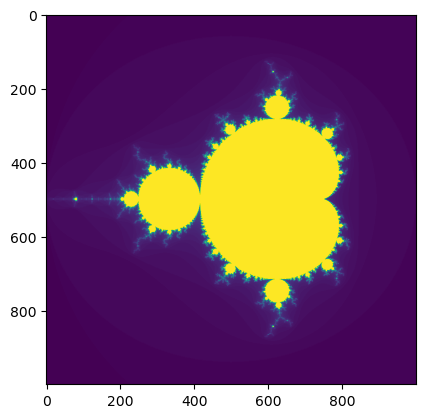

**Co je Mandelbrotova množina?**

Mandelbrotova množina je množina komplexních čísel $c$, pro které platí, že posloupnost $z_{i+1} = z_i^2 + c$ s $z_0 = 0$ nekonverguje do nekonečna (tj. $|z_i|$ zůstává omezené).

**Co tedy udělat?**
- vytvořte matici $n\times n$ komplexních čísel $c$ na intervalu $[-2, 1] \times [-1.5, 1.5]$ (pomocí `np.mgrid` nebo `np.meshgrid`),
    - využijte výhody vektorizace a toho, že NumPy umí násobit komplexní čísla,
- stanovte si počet iterací $k$, pro které budete testovat, zda posloupnost nedivergovala,
    - divergování posloupnosti poznáme tak, že $|z_i| > 2$ pro nějaké $i$,
- proveďte $k$ iterací posloupnosti $z_{i+1} = z_i^2 + c$ a zjistěte, ve které iteraci nastalo $|z_i| > 2$ (jakmile to nastane jednou, bude to platit pro všechna další $i$),
    - použijte pomocnou matici `divergence_matrix`, která bude mít stejný rozměr jako `c` a bude obsahovat počet iterací, kdy $|z_i| < 2$ pro každé $c$,
- vytvořte obrázek pomocí `imshow` z `divergence_matrix`.

In [24]:
def mandelbrot_set(x_min = -2, x_max = 1, y_min = -1.5, y_max = 1.5, n = 1000, k = 100):
    # Vytvoření mřížky bodů na daném intervalu
    x = np.linspace(x_min, x_max, n)
    y = np.linspace(y_min, y_max, n)
    X, Y = np.meshgrid(x, y)
    
    # Převod 2D mřížky na komplexní rovinu a j je imaginární jednotka
    C = X + 1j * Y
    
    # Inicializace Z vytvopřením matice stejné velikosti jako C, naplněné nulami
    Z = np.zeros_like(C)
    divergence_matrix = np.zeros(C.shape, dtype=int)
    
    for _ in range(k):
        # Maska: vybereme jen ty body, které ještě neutekly do nekonečna kde abs funguje jako modulo jen pro numpy
        mask = np.abs(Z) <= 2
        
        # Výpočet z_i+1 = z_i^2 + c 
        Z[mask] = Z[mask]**2 + C[mask]
        
        # Inkrementujeme počet přežití u bodů
        divergence_matrix[mask] += 1
        
    return divergence_matrix

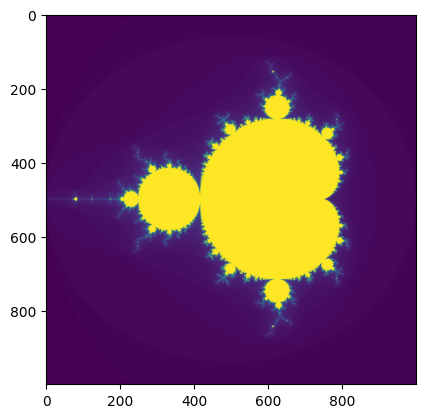

In [25]:
n = 1000
k = 100

divergence_matrix = mandelbrot_set(n=n, k=k)
plt.imshow(divergence_matrix)

## Bonusové úkoly
1. Vykreslete také Juliovu množinu (viz https://en.wikipedia.org/wiki/Julia_set).
2. Použijte váš kód pro číselnou spirálu a vytvořte obrázek prvočíselné spirály (viz https://en.wikipedia.org/wiki/Ulam_spiral).